# Analyzing the natural images filters

1. Pre-loading model and necessary functions

In [1]:
#!pip install torch_xla
import torch
import os
from typing import Optional
#import torch_xla.utils.serialization as ser
def load_checkpoint(model, optimizer: Optional[None], path ="/kaggle/input/"):
    """
    Loads a saved state and updates the model and optimizer.
    """
    if os.path.exists(f'{path}'):
        checkpoint = torch.load(path, map_location=torch.device('cpu'))
        load_status = model.load_state_dict(checkpoint['state_dict'], strict=False)
        print(f'The load_status is {load_status}')
        if optimizer is not None:
            optimizer.load_state_dict(checkpoint['optimizer'])
        epoch = checkpoint['epoch']
        loss = checkpoint['loss']
        print(f"Reverting the model from epoch {epoch} with loss {loss:.4f}")
        return epoch
    else:
        print("No checkpoint found at this path.")
        return 0

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

def init_weights(m):
    # Check if the sub-module is a Linear layer
    if isinstance(m, nn.Linear):
        # Reach inside the module and grab the 'weight' tensor
        nn.init.xavier_uniform_(m.weight)
        # Often we initialize biases to a small constant or zero
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.01)
            
    # Check if it's a Convolutional layer
    elif isinstance(m, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)

class PseudoAlexNet(nn.Module):
    def __init__(self):
        super(PseudoAlexNet, self).__init__()
        
        # 1. Define the Sequential block first
        # This will be registered as 'features.0', 'features.1', etc.
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=7, stride=3, padding=3),  # Index 0
            nn.BatchNorm2d(96),                                   # Index 1
            nn.Conv2d(96, 128, kernel_size=5, stride=2, padding=2), # Index 2
            nn.BatchNorm2d(128),                                  # Index 3
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),# Index 4
            nn.BatchNorm2d(256),                                  # Index 5
            nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),# Index 6
            nn.BatchNorm2d(384)                                   # Index 7
        )

        # 2. Create "Pointers" for the forward pass
        # These are just references, they don't create new keys in state_dict
        self.conv1, self.bn1 = self.features[0], self.features[1]
        self.conv2, self.bn2 = self.features[2], self.features[3]
        self.conv3, self.bn3 = self.features[4], self.features[5]
        self.conv4, self.bn4 = self.features[6], self.features[7]

        # 3. Classifier
        self.fc1 = nn.Linear(384 * 12 * 8, 256)
        self.bn_fc = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 101)

    def forward(self, x):
        # Layer 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        
        # Layer 2 + Pool
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        
        # Layer 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        
        # Layer 4 + Pool
        x = self.conv4(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        
        # Flatten
        x = x.view(x.size(0), -1) 
        
        # Fully Connected 1
        x = self.fc1(x)
        x = self.bn_fc(x)
        x = F.relu(x)
        
        # Output
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

2. Preloading weights of the peak natural images training

In [3]:
CHECKPOINTS_PATH = "/kaggle/input/datasets/nazariyyuchnovskiy/20-checkpoint-batchnorm"
model = PseudoAlexNet()

#model.to(device)


load_checkpoint(model=model, optimizer=None, path=f'{CHECKPOINTS_PATH}/best_accuracy_nat_images_checkpoint.pth')

The load_status is _IncompatibleKeys(missing_keys=['features.0.weight', 'features.0.bias', 'features.1.weight', 'features.1.bias', 'features.1.running_mean', 'features.1.running_var', 'features.2.weight', 'features.2.bias', 'features.3.weight', 'features.3.bias', 'features.3.running_mean', 'features.3.running_var', 'features.4.weight', 'features.4.bias', 'features.5.weight', 'features.5.bias', 'features.5.running_mean', 'features.5.running_var', 'features.6.weight', 'features.6.bias', 'features.7.weight', 'features.7.bias', 'features.7.running_mean', 'features.7.running_var'], unexpected_keys=[])
Reverting the model from epoch 20 with loss 0.0122


20

Checking the availabilit of the GPU and the pytorch's pre-loaded wheels.

In [4]:
import torch
print(f"Device: {torch.cuda.get_device_name(0)}")
print(f"Compute Capability: {torch.cuda.get_device_capability(0)}")
# Should return (6, 0)

Device: Tesla T4
Compute Capability: (7, 5)


3. Creating the FilterVisualizer pattern according to (https://keras.io/examples/vision/visualizing_what_convnets_learn/). Activation Maximization (Feature Visualization)

In [6]:
import torch
import torch.nn as nn
import numpy as np

print(torch.cuda.is_available())
class FilterVisualizer:
    def __init__(self, model, layer_num):
        # Automatically detect CUDA
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        # Move model to device and set to eval mode
        self.model = model.to(self.device).eval()
        
        for param in self.model.parameters():
            param.requires_grad = False
            
        self.layer_num = layer_num
        
        # Access the target layer
        target_layer = self.model.features[self.layer_num]
        if hasattr(target_layer, 'out_channels'):
            self.total_filters = target_layer.out_channels
        elif hasattr(target_layer, 'num_features'): 
            self.total_filters = target_layer.num_features
        else:
            self.total_filters = None

    def visualize(self, filter_indices=None, iterations=30, lr=0.1, size=(300, 200)):
        if filter_indices is None:
            if self.total_filters is None:
                raise ValueError("Could not determine filter count. Please pass indices manually.")
            indices = list(range(self.total_filters))
        elif isinstance(filter_indices, int):
            indices = [filter_indices]
        elif isinstance(filter_indices, range):
            indices = list(filter_indices)
        else:
            indices = filter_indices

        num_to_viz = len(indices)
        
        # 1. Create noise tensor directly on the GPU
        img = torch.randn(num_to_viz, 3, size[0], size[1], requires_grad=True,
                         device=self.device)
        
        optimizer = torch.optim.Adam([img], lr=lr, weight_decay=1e-6)

        for i in range(iterations):
            optimizer.zero_grad()
            
            x = img
            for idx, layer in enumerate(self.model.features):
                x = layer(x)
                if idx == self.layer_num:
                    break
            
            # 2. Advanced indexing tensors must also be on the same device
            batch_idx = torch.arange(num_to_viz, device=self.device)
            
            # Ensure indices is a tensor on the correct device
            filter_idx_tensor = torch.tensor(indices, device=self.device)
            
            target_activations = x[batch_idx, filter_idx_tensor, :, :]
            
            loss = torch.mean(target_activations)
            
            loss.backward()
            optimizer.step()
            img.data.clamp_(0, 1)

        return self.deprocess_batch(img, indices)

    def deprocess_batch(self, img_batch, indices):
        # 3. Move back to CPU and convert to NumPy for plotting
        img_batch = img_batch.detach().cpu()
        
        return {idx: img_batch[i] for i, idx in enumerate(indices)}

# --- Usage ---
visualizer = FilterVisualizer(model, layer_num=4)
patterns = visualizer.visualize(filter_indices=None)

True


In [10]:
visualizer = FilterVisualizer(model, layer_num=6)
patterns_6 = visualizer.visualize(filter_indices=None)

4. Visualizations for the filter of the two last convolutional layers which were made trainable.

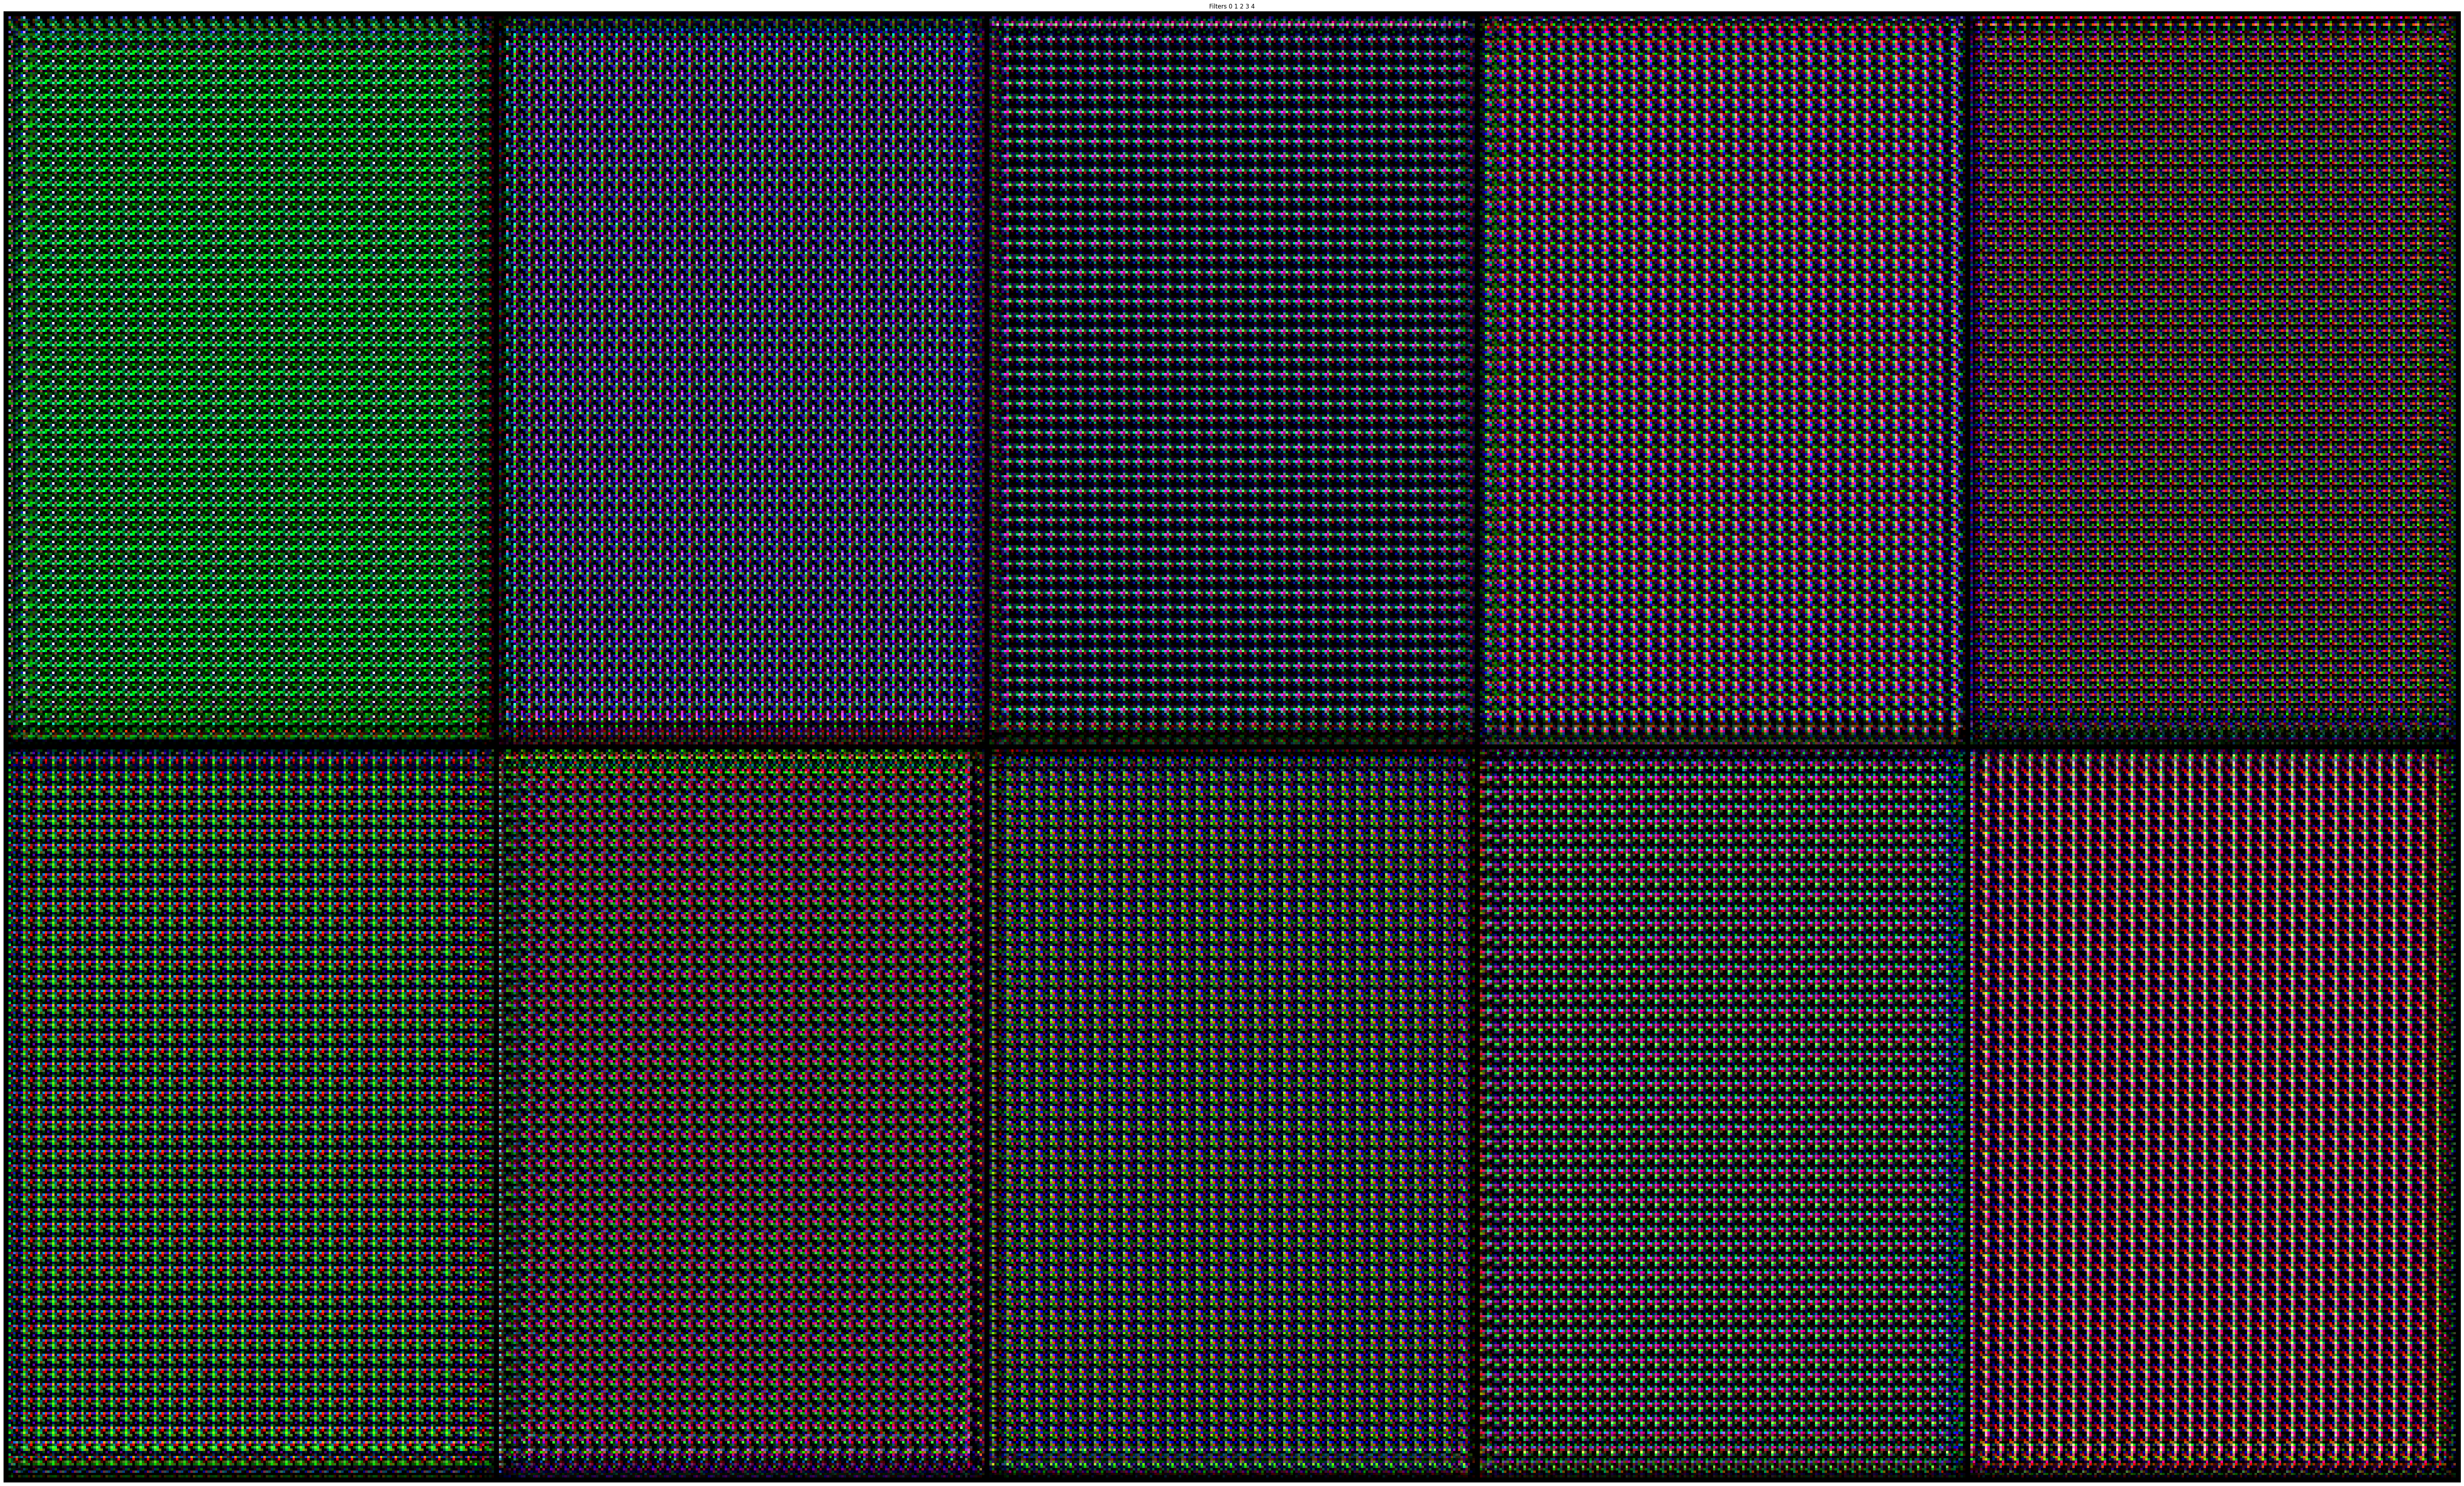

In [13]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

patterns_nat_images_4 = patterns
patterns_nat_images_6 = patterns_6
def plot_tensor_batch(batch_tensor, title="Image Batch"):
    # 1. Create a grid (padding adds a border between images)
    grid = vutils.make_grid(batch_tensor, nrow=5, padding=2, normalize=True)
    
    # 2. Convert from (C, H, W) to (H, W, C) for Matplotlib
    plt.figure(figsize=(128, 54))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.title(title)
    plt.axis("off")
    plt.show()

plot_tensor_batch(batch_tensor = list(patterns_6.values())[:10], title="Filters 0 1 2 3 4")

# Analyzing the fine-tuned model after the digital screens

1. Rewrite of the model since the model input size was different

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class PseudoAlexNetFT(nn.Module):
    def __init__(self):
        super(PseudoAlexNetFT, self).__init__()
        
        # 1. Define the Sequential block first
        # This will be registered as 'features.0', 'features.1', etc.
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=7, stride=3, padding=3),  # Index 0
            nn.BatchNorm2d(96),                                   # Index 1
            nn.Conv2d(96, 128, kernel_size=5, stride=2, padding=2), # Index 2
            nn.BatchNorm2d(128),                                  # Index 3
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),# Index 4
            nn.BatchNorm2d(256),                                  # Index 5
            nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),# Index 6
            nn.BatchNorm2d(384)                                   # Index 7
        )

        # 2. Create "Pointers" for the forward pass
        # These are just references, they don't create new keys in state_dict
        self.conv1, self.bn1 = self.features[0], self.features[1]
        self.conv2, self.bn2 = self.features[2], self.features[3]
        self.conv3, self.bn3 = self.features[4], self.features[5]
        self.conv4, self.bn4 = self.features[6], self.features[7]

        # 3. Classifier
        self.fc1 = nn.Linear(384 * 13 * 7, 256)
        self.bn_fc = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 16)

    def forward(self, x):
        # Layer 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        
        # Layer 2 + Pool
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        
        # Layer 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        
        # Layer 4 + Pool
        x = self.conv4(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        
        # Flatten
        x = x.view(x.size(0), -1) 
        
        # Fully Connected 1
        x = self.fc1(x)
        x = self.bn_fc(x)
        x = F.relu(x)
        
        # Output
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

In [19]:
CHECKPOINTS_PATH = "/kaggle/input/datasets/nazariyyuchnovskiy/20-checkpoint-batchnorm"
model = PseudoAlexNetFT()

load_checkpoint(model=model, optimizer=None, path=f'{CHECKPOINTS_PATH}/drift_finish_checkpoint.pth')

RuntimeError: Error(s) in loading state_dict for PseudoAlexNetFT:
	size mismatch for fc2.weight: copying a param with shape torch.Size([16, 256]) from checkpoint, the shape in current model is torch.Size([101, 256]).
	size mismatch for fc2.bias: copying a param with shape torch.Size([16]) from checkpoint, the shape in current model is torch.Size([101]).